In [1]:
import psi4
import pandas as pd
import os
import numpy as np
from lps_uscf import lps_solver
%matplotlib inline
import matplotlib.pyplot as plt

In [19]:
csv_file = 'all_atoms_vs_uhf.csv'

if os.path.exists(csv_file):
    df = pd.read_csv(csv_file)
    print(f"-> Loaded existing results: {len(df)} rows found.")
else:
    df = pd.DataFrame()
    print("-> No existing file found. Starting fresh.")

-> Loaded existing results: 327 rows found.


In [20]:
pd.set_option('display.precision', 4)
df[(df['Method'] == 'TF0.166666W LDA')]

,Method,Atom,Basis,Grid_Sph,Grid_Rad,"Energy,Ha",Iterations,DIIS,Damp_Start,Damp_End,Damp_Cutoff
90,TF0.166666W LDA,H,UGBS_S,6,1000,-0.4688,113,True,0.90,0.90,1.0000e-04
91,TF0.166666W LDA,He,UGBS_S,6,1000,-2.9512,200,True,0.90,0.90,1.0000e-04
92,TF0.166666W LDA,Li,UGBS_S,6,1000,-7.5992,250,True,0.90,0.90,1.0000e-04
93,TF0.166666W LDA,Be,UGBS_S,6,1000,-15.0404,296,True,0.90,0.90,1.0000e-04
94,TF0.166666W LDA,B,UGBS_S,6,1000,-25.4891,763,True,0.90,0.90,1.0000e-04
95,TF0.166666W LDA,C,UGBS_S,6,1000,-39.2018,586,True,0.90,0.90,1.0000e-04
96,TF0.166666W LDA,N,UGBS_S,6,1000,-56.3704,4071,True,0.90,0.90,1.0000e-04
97,TF0.166666W LDA,O,UGBS_S,6,1000,-77.8154,3417,True,0.90,0.90,1.0000e-04
98,TF0.166666W LDA,F,UGBS_S,6,1000,-103.0992,6471,True,0.90,0.90,1.0000e-04
99,TF0.166666W LDA,Ne,UGBS_S,6,1000,-132.5089,680,True,0.90,0.90,1.0000e-04


In [21]:
pd.set_option('display.precision', 4)
df[(df['Method'] == 'TF0.166666W FA')]

,Method,Atom,Basis,Grid_Sph,Grid_Rad,"Energy,Ha",Iterations,DIIS,Damp_Start,Damp_End,Damp_Cutoff
110,TF0.166666W FA,H,UGBS_S,6,1000,-0.4970,107,True,0.90,0.90,1.0000e-04
111,TF0.166666W FA,He,UGBS_S,6,1000,-3.0195,177,True,0.90,0.90,1.0000e-04
112,TF0.166666W FA,Li,UGBS_S,6,1000,-7.5233,260,True,0.90,0.90,1.0000e-04
113,TF0.166666W FA,Be,UGBS_S,6,1000,-14.6605,490,True,0.90,0.90,1.0000e-04
114,TF0.166666W FA,B,UGBS_S,6,1000,-24.7412,464,True,0.90,0.90,1.0000e-04
115,TF0.166666W FA,C,UGBS_S,6,1000,-38.0152,696,True,0.90,0.90,1.0000e-04
116,TF0.166666W FA,N,UGBS_S,6,1000,-54.6665,525,True,0.90,0.90,1.0000e-04
117,TF0.166666W FA,O,UGBS_S,6,1000,-75.3393,3806,True,0.90,0.90,1.0000e-04
118,TF0.166666W FA,F,UGBS_S,6,1000,-99.7793,1304,True,0.90,0.90,1.0000e-04
119,TF0.166666W FA,Ne,UGBS_S,6,1000,-128.2917,494,True,0.90,0.90,1.0000e-04


In [10]:
atom_order = ['H', 'He', 'Li', 'Be', 'B', 'C', 'N', 'O', 'F', 'Ne', 'Na', 'Mg', 'Al', 'Si', 'P', 'S', 'Cl', 'Ar', 'Ca', 'Zn', 'Kr']
energy_table = df.pivot(index='Atom', columns='Method', values='Iterations')
energy_table = energy_table.reindex(atom_order)
pd.set_option('display.precision', 0)
display(energy_table)

Method,TF0.111111W FA,TF0.111111W LDA,TF0.111111W PBE,TF0.166666W FA,TF0.166666W LDA,TF0.166666W PBE,TF0.2W FA,TF0.2W LDA,TF0.2W PBE,TF0.333333W FA,TF0.333333W LDA,TF0.333333W PBE,TFW FA,TFW LDA,TFW PBE
Atom,,,,,,,,,,,,,,,
H,478,250,178,107,113,133,142,110,97,82,44,87,30,30,31
He,156,224,349,177,200,270,144,172,273,128,106,178,55,52,51
Li,538,2098,1202,260,250,346,231,371,256,201,139,263,79,74,82
Be,379,448,430,490,296,325,229,228,331,158,115,157,76,77,74
B,557,1283,8228,464,763,487,274,479,500,212,253,277,97,96,123
C,4988,7545,6540,696,586,873,388,843,931,237,461,308,108,113,107
N,2001,1604,3992,525,4071,998,400,792,497,334,354,336,123,132,123
O,1931,1153,6304,3806,3417,5007,951,517,1344,303,360,560,132,141,241
F,1186,9847,6700,1304,6471,2944,1832,564,4658,306,1004,283,179,169,167


In [4]:
lda = energy_table['TF0.166666W LDA'].tolist()
pbe = energy_table['TF0.166666W PBE'].tolist()
fa = energy_table['TF0.166666W FA'].tolist()

In [6]:
print('LDA: ', energy_table['TF0.166666W LDA'].mean(), '\n'
      'PBE: ', np.round(energy_table['TF0.166666W PBE'].mean(), 0), '\n'
      'FA:  ', np.round(energy_table['TF0.166666W FA'].mean(), 0))

LDA:  3838.0 
PBE:  5079.0 
FA:   3504.0


In [7]:
print('LDA: ', np.round(energy_table['TF0.111111W LDA'].mean(), 0), '\n'
      'PBE: ', np.round(energy_table['TF0.111111W PBE'].mean(), 0), '\n'
      'FA:  ', np.round(energy_table['TF0.111111W FA'].mean(), 0))

LDA:  5697.0 
PBE:  9256.0 
FA:   5821.0


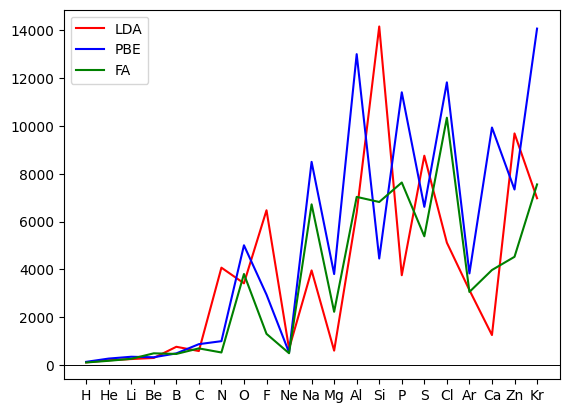

In [8]:
plt.plot(atom_order, lda, color = 'red', linestyle='-', label='LDA')
plt.plot(atom_order, pbe, color = 'blue', linestyle='-', label='PBE')
plt.plot(atom_order, fa, color = 'green', linestyle='-', label='FA')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.7)
plt.legend()

In [10]:
# pd.set_option('display.precision', 4)
# df[(df['Method'] == 'TF0.166666W LDA')]